<a href="https://colab.research.google.com/github/yashdevale25/Data-Science-Lab/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression – House Price Prediction

Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Upload Dataset (Colab)

In [4]:
from google.colab import files
uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


Step 3: Load Dataset

In [6]:
df = pd.read_csv('HousingData.csv')  # use your exact file name
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


Step 4: Explore Data

In [7]:
print(df.shape)
print(df.info())
print(df.describe())

(506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0

Step 5: Check Missing Values

In [8]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


Step 6: Select Features and Target

In [25]:
df = df.fillna(df.mean())
X = df.drop('MEDV', axis=1)   # Features
y = df['MEDV']                # Target (House Price)

Step 7: Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 8: Train Linear Regression Model

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 9: Make Predictions

In [28]:
y_pred = model.predict(X_test)

Step 10: Evaluate Model

In [29]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 25.01767202384268
R2 Score: 0.6588520195508143


Step 11: Compare Actual vs Predicted

In [30]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head())

   Actual  Predicted
0    23.6  29.143250
1    32.4  36.535668
2    13.6  14.492513
3    22.8  25.081110
4    16.1  18.456092


Step 12: Visualization

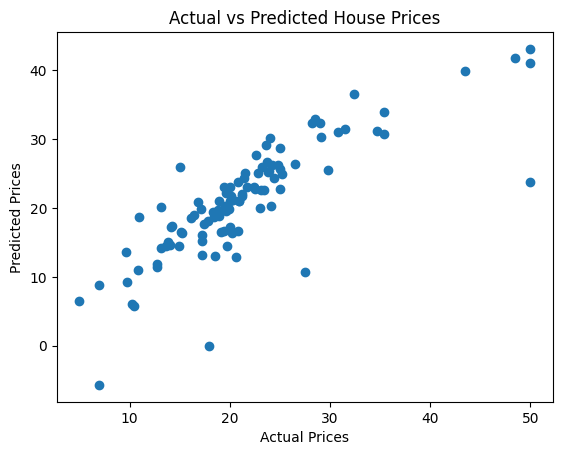

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

Step 13: Feature Importance (Coefficients)

In [32]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

    Feature  Coefficient
5        RM     4.752410
3      CHAS     3.240673
8       RAD     0.222823
1        ZN     0.029016
11        B     0.012263
9       TAX    -0.009151
6       AGE    -0.019520
2     INDUS    -0.027133
0      CRIM    -0.114140
12    LSTAT    -0.438440
10  PTRATIO    -0.886045
7       DIS    -1.521593
4       NOX   -16.017543
